# Data Analysis Notebook

This notebook uses data in the `/logs` directory 

In [9]:
#Tests where made in Windows, directory separator is set to '\'
base_directory = ".\\logs"

In [14]:
columns = ["Bus Voltage", "Power", "Current"]
graphs = ["Bus Voltage (V)", "Power(mW)", "Current (mA)"]

## LoRa Sender

Energy analysis of the Heltec WiFi LoRa 32 V3 with no extra hardware.

In [15]:
from glob import glob
import pandas as pd
import matplotlib.pyplot as plt

files_path = "\\".join([base_directory, "V3Sender"])
files = glob(files_path+"\\*.csv")
idle_file = pd.read_csv(str(files.pop()))

In [16]:
file = pd.read_csv(files[0])
for g in columns:
    file[g] = [float(m.split(' ')[0]) for m in file[g]]
for g in columns:
    idle_file[g] = [float(m.split(' ')[0]) for m in idle_file[g]]

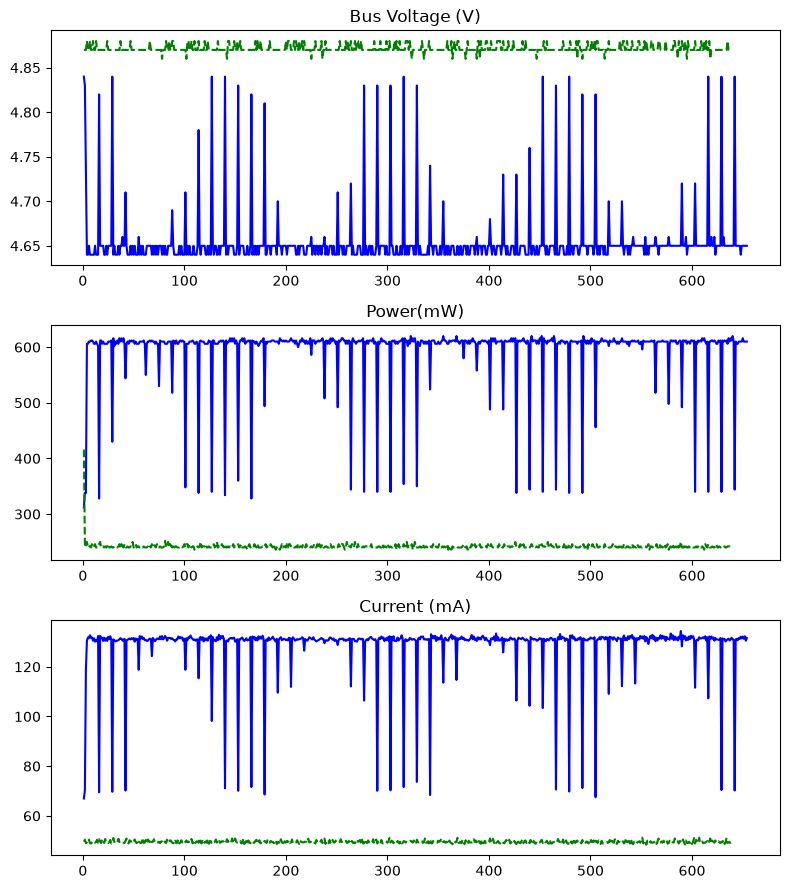

In [21]:

fig, axes = plt.subplots(3, 1, figsize=(8, 9))
for i in range(0,3):
        axes[i].plot(range(1,len(file[columns[i]])+1), file[columns[i]], '-b', label="transmission")
        axes[i].plot(range(1,len(idle_file[columns[i]])+1), idle_file[columns[i]], '--g', label="idle")
        axes[i].set_title(graphs[i])
plt.tight_layout()
plt.show()

In [22]:
file.describe()

,Bus Voltage,Power,Current
count,654.000000,654.000000,654.000000
mean,4.654709,596.740061,128.776911
std,0.035714,55.098545,11.048404
min,4.640000,312.000000,67.000000
25%,4.640000,606.000000,130.700000
50%,4.650000,610.000000,131.200000
75%,4.650000,612.000000,131.600000
max,4.840000,620.000000,134.400000


In [24]:
print(file[columns[2]].max())
print(idle_file[columns[2]].max())

134.4
51.3
